# Setup & Import Libraries

In [1]:
import subprocess
import sys

try:
    import spacy
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "spacy", "--break-system-packages", "-q"])
    import spacy

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")

print(f"spaCy version: {spacy.__version__}")
print(f"Loaded pipeline: en_core_web_sm")
print(f"Pipeline components: {nlp.pipe_names}")

spaCy version: 3.8.4
Loaded pipeline: en_core_web_sm
Pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [2]:
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from spacy import displacy
from IPython.display import display, HTML

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Sample Text Data

In [3]:
sample_texts = {
    "tech_news": (
        "Tim Cook announced on September 12, 2023 that Apple would open a new research "
        "center in Austin, Texas. The event, held in partnership with the University of "
        "Texas, was also attended by representatives from Microsoft and NASA."
    ),
    "history": (
        "Nelson Mandela was released from prison in South Africa on February 11, 1990, "
        "after being held for 27 years. He later became President and worked closely with "
        "the African National Congress and the United Nations to promote reconciliation."
    ),
    "business": (
        "In March 2024, Amazon confirmed plans to expand its logistics hub near Seattle, "
        "Washington. CEO Andy Jassy said the company would also invest in facilities in "
        "Berlin and Tokyo before the end of 2025."
    ),
    "sports": (
        "Serena Williams won her first Grand Slam title in New York back in 1999. She has "
        "since worked with organizations such as UNICEF and appeared at events hosted by "
        "the International Olympic Committee."
    ),
}

for name, text in sample_texts.items():
    print(f"[{name}]\n{text}\n")

[tech_news]
Tim Cook announced on September 12, 2023 that Apple would open a new research center in Austin, Texas. The event, held in partnership with the University of Texas, was also attended by representatives from Microsoft and NASA.

[history]
Nelson Mandela was released from prison in South Africa on February 11, 1990, after being held for 27 years. He later became President and worked closely with the African National Congress and the United Nations to promote reconciliation.

[business]
In March 2024, Amazon confirmed plans to expand its logistics hub near Seattle, Washington. CEO Andy Jassy said the company would also invest in facilities in Berlin and Tokyo before the end of 2025.

[sports]
Serena Williams won her first Grand Slam title in New York back in 1999. She has since worked with organizations such as UNICEF and appeared at events hosted by the International Olympic Committee.



# Run Named Entity Recognition with spaCy

In [4]:
docs = {name: nlp(text) for name, text in sample_texts.items()}

entity_rows = []
for name, doc in docs.items():
    for ent in doc.ents:
        entity_rows.append({
            "source": name,
            "entity_text": ent.text,
            "label": ent.label_,
            "label_description": spacy.explain(ent.label_),
            "start_char": ent.start_char,
            "end_char": ent.end_char,
        })

entities_df = pd.DataFrame(entity_rows)
entities_df

,source,entity_text,label,label_description,start_char,end_char
0,tech_news,Tim Cook,PERSON,"People, including fictional",0,8
1,tech_news,"September 12, 2023",DATE,Absolute or relative dates or periods,22,40
2,tech_news,Apple,ORG,"Companies, agencies, institutions, etc.",46,51
3,tech_news,Austin,GPE,"Countries, cities, states",88,94
4,tech_news,Texas,GPE,"Countries, cities, states",96,101
5,tech_news,the University of Texas,ORG,"Companies, agencies, institutions, etc.",139,162
6,tech_news,Microsoft,ORG,"Companies, agencies, institutions, etc.",206,215
7,tech_news,NASA,ORG,"Companies, agencies, institutions, etc.",220,224
8,history,Nelson Mandela,PERSON,"People, including fictional",0,14
9,history,South Africa,GPE,"Countries, cities, states",43,55


# Focus on the Requested Entity Types

In [5]:
LABEL_MAP = {
    "PERSON": "PERSON",
    "GPE": "LOCATION",
    "LOC": "LOCATION",
    "ORG": "ORGANIZATION",
    "DATE": "DATE",
}

entities_df["category"] = entities_df["label"].map(LABEL_MAP)
focused_df = entities_df[entities_df["category"].notna()].reset_index(drop=True)

focused_df[["source", "entity_text", "label", "category"]]

,source,entity_text,label,category
0,tech_news,Tim Cook,PERSON,PERSON
1,tech_news,"September 12, 2023",DATE,DATE
2,tech_news,Apple,ORG,ORGANIZATION
3,tech_news,Austin,GPE,LOCATION
4,tech_news,Texas,GPE,LOCATION
5,tech_news,the University of Texas,ORG,ORGANIZATION
6,tech_news,Microsoft,ORG,ORGANIZATION
7,tech_news,NASA,ORG,ORGANIZATION
8,history,Nelson Mandela,PERSON,PERSON
9,history,South Africa,GPE,LOCATION


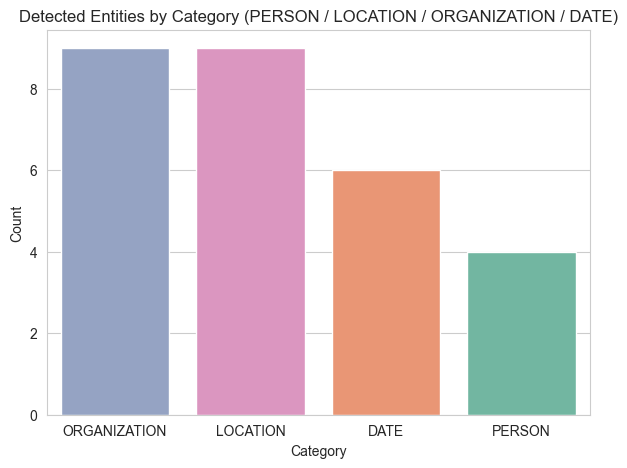

In [6]:
plt.figure()
sns.countplot(data=focused_df, x="category", hue="category",
              order=focused_df["category"].value_counts().index, palette="Set2", legend=False)
plt.title("Detected Entities by Category (PERSON / LOCATION / ORGANIZATION / DATE)")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

# Compare with NLTK's NER (`ne_chunk`)

In [7]:
for pkg in ["punkt_tab", "averaged_perceptron_tagger_eng", "maxent_ne_chunker_tab", "words"]:
    nltk.download(pkg, quiet=True)

def nltk_ner(text):
    tokens = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    tree = nltk.ne_chunk(pos_tags)

    entities = []
    for subtree in tree:
        if hasattr(subtree, "label"):
            entity_text = " ".join(word for word, tag in subtree)
            entities.append((entity_text, subtree.label()))
    return entities


comparison_text = sample_texts["tech_news"]
nltk_entities = nltk_ner(comparison_text)
spacy_entities = [(ent.text, ent.label_) for ent in docs["tech_news"].ents]

comparison_df = pd.DataFrame({
    "spaCy entities": pd.Series([f"{t} ({l})" for t, l in spacy_entities]),
    "NLTK entities": pd.Series([f"{t} ({l})" for t, l in nltk_entities]),
})
comparison_df

,spaCy entities,NLTK entities
0,Tim Cook (PERSON),Tim (PERSON)
1,"September 12, 2023 (DATE)",Cook (PERSON)
2,Apple (ORG),Apple (PERSON)
3,Austin (GPE),Austin (GPE)
4,Texas (GPE),Texas (GPE)
5,the University of Texas (ORG),University (ORGANIZATION)
6,Microsoft (ORG),Texas (GPE)
7,NASA (ORG),Microsoft (ORGANIZATION)
8,NaN,NASA (ORGANIZATION)


# Visualize Detected Entities

In [9]:
for name, doc in docs.items():
    print(f"--- {name} ---")
    html = displacy.render(doc, style="ent", jupyter=False)
    display(HTML(html))

--- tech_news ---


--- history ---


--- business ---


--- sports ---


# Evaluate Model Performance

In [10]:
gold_standard = [
    (
        "Elon Musk founded SpaceX in California in 2002.",
        [("Elon Musk", "PERSON"), ("SpaceX", "ORGANIZATION"),
         ("California", "LOCATION"), ("2002", "DATE")],
    ),
    (
        "Angela Merkel served as Chancellor of Germany until December 2021.",
        [("Angela Merkel", "PERSON"), ("Germany", "LOCATION"), ("December 2021", "DATE")],
    ),
    (
        "Google opened a new office in London in January 2020.",
        [("Google", "ORGANIZATION"), ("London", "LOCATION"), ("January 2020", "DATE")],
    ),
    (
        "Marie Curie worked at the University of Paris and won a Nobel Prize in 1911.",
        [("Marie Curie", "PERSON"), ("University of Paris", "ORGANIZATION"), ("1911", "DATE")],
    ),
    (
        "The United Nations held a summit in Geneva on March 3, 2019.",
        [("The United Nations", "ORGANIZATION"), ("Geneva", "LOCATION"),
         ("March 3, 2019", "DATE")],
    ),
    (
        "Jeff Bezos stepped down as CEO of Amazon in July 2021.",
        [("Jeff Bezos", "PERSON"), ("Amazon", "ORGANIZATION"), ("July 2021", "DATE")],
    ),
    (
        "Cristiano Ronaldo joined Al Nassr, a club based in Saudi Arabia, in 2023.",
        [("Cristiano Ronaldo", "PERSON"), ("Al Nassr", "ORGANIZATION"),
         ("Saudi Arabia", "LOCATION"), ("2023", "DATE")],
    ),
    (
        "The World Health Organization released new guidelines in Geneva last May.",
        [("The World Health Organization", "ORGANIZATION"), ("Geneva", "LOCATION")],
    ),
]

print(f"Gold-standard sentences: {len(gold_standard)}")
print(f"Total gold entities: {sum(len(ents) for _, ents in gold_standard)}")

Gold-standard sentences: 8
Total gold entities: 25


In [11]:
def get_spacy_predictions(text):
    doc = nlp(text)
    preds = []
    for ent in doc.ents:
        category = LABEL_MAP.get(ent.label_)
        if category:
            preds.append((ent.text, category))
    return preds


def normalize(entity_text):
    return re.sub(r"^(the)\s+", "", entity_text.strip().lower())


eval_rows = []
tp_by_cat, fp_by_cat, fn_by_cat = {}, {}, {}

for text, gold_entities in gold_standard:
    predicted_entities = get_spacy_predictions(text)

    gold_set = {(normalize(t), c) for t, c in gold_entities}
    pred_set = {(normalize(t), c) for t, c in predicted_entities}

    matched_gold = set()
    matched_pred = set()

    for g in gold_set:
        for p in pred_set:
            if p in matched_pred:
                continue
            # match if same category and either exact text match or one contains the other
            if g[1] == p[1] and (g[0] == p[0] or g[0] in p[0] or p[0] in g[0]):
                matched_gold.add(g)
                matched_pred.add(p)
                break

    tp = len(matched_gold)
    fn = len(gold_set) - len(matched_gold)
    fp = len(pred_set) - len(matched_pred)

    for g in matched_gold:
        tp_by_cat[g[1]] = tp_by_cat.get(g[1], 0) + 1
    for g in gold_set - matched_gold:
        fn_by_cat[g[1]] = fn_by_cat.get(g[1], 0) + 1
    for p in pred_set - matched_pred:
        fp_by_cat[p[1]] = fp_by_cat.get(p[1], 0) + 1

    eval_rows.append({
        "text": text,
        "gold_entities": gold_entities,
        "predicted_entities": predicted_entities,
        "true_positives": tp,
        "false_negatives": fn,
        "false_positives": fp,
    })

eval_df = pd.DataFrame(eval_rows)
eval_df[["text", "true_positives", "false_positives", "false_negatives"]]

,text,true_positives,false_positives,false_negatives
0,Elon Musk founded SpaceX in California in 2002.,3,0,1
1,Angela Merkel served as Chancellor of Germany ...,3,0,0
2,Google opened a new office in London in Januar...,3,0,0
3,Marie Curie worked at the University of Paris ...,3,0,0
4,The United Nations held a summit in Geneva on ...,3,0,0
5,Jeff Bezos stepped down as CEO of Amazon in Ju...,3,0,0
6,"Cristiano Ronaldo joined Al Nassr, a club base...",3,1,1
7,The World Health Organization released new gui...,2,1,0


In [12]:
categories = sorted(set(list(tp_by_cat) + list(fp_by_cat) + list(fn_by_cat)))
metric_rows = []

total_tp = total_fp = total_fn = 0

for cat in categories:
    tp = tp_by_cat.get(cat, 0)
    fp = fp_by_cat.get(cat, 0)
    fn = fn_by_cat.get(cat, 0)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    metric_rows.append({
        "category": cat, "precision": round(precision, 3),
        "recall": round(recall, 3), "f1_score": round(f1, 3),
        "support": tp + fn,
    })
    total_tp += tp
    total_fp += fp
    total_fn += fn

overall_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
overall_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
overall_f1 = (2 * overall_precision * overall_recall / (overall_precision + overall_recall)
              if (overall_precision + overall_recall) > 0 else 0.0)

metrics_df = pd.DataFrame(metric_rows).set_index("category")
print(f"Overall Precision: {overall_precision:.3f}")
print(f"Overall Recall:    {overall_recall:.3f}")
print(f"Overall F1-Score:  {overall_f1:.3f}\n")
metrics_df

Overall Precision: 0.920
Overall Recall:    0.920
Overall F1-Score:  0.920



,precision,recall,f1_score,support
category,,,,
DATE,0.875,1.000,0.933,7
LOCATION,1.000,1.000,1.000,6
ORGANIZATION,1.000,0.714,0.833,7
PERSON,0.833,1.000,0.909,5


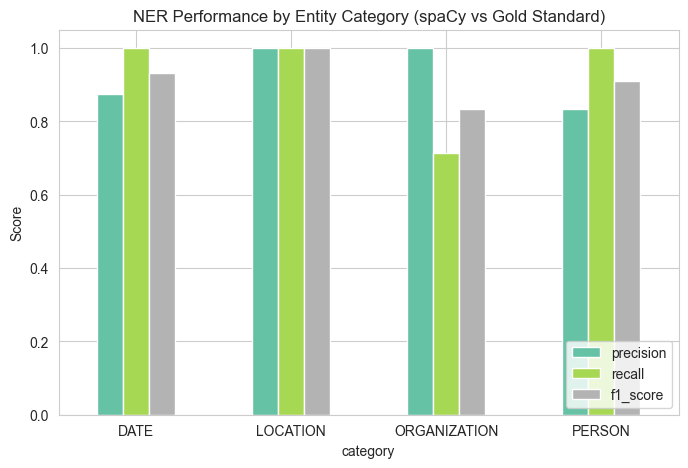

In [13]:
metrics_df[["precision", "recall", "f1_score"]].plot(kind="bar", figsize=(8, 5), colormap="Set2")
plt.title("NER Performance by Entity Category (spaCy vs Gold Standard)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.show()

# Try It Yourself: Extract Entities from Custom Text

In [14]:
custom_text = (
    "Satya Nadella, CEO of Microsoft, met with officials in Paris on June 15, 2024 to "
    "discuss a new partnership with the European Union."
)

custom_doc = nlp(custom_text)

print("Detected entities:\n")
for ent in custom_doc.ents:
    category = LABEL_MAP.get(ent.label_, ent.label_)
    print(f"  {ent.text:<30} {ent.label_:<10} ({category})")

print()
displacy.render(custom_doc, style="ent", jupyter=True)

Detected entities:

  Satya Nadella                  PERSON     (PERSON)
  Microsoft                      ORG        (ORGANIZATION)
  Paris                          GPE        (LOCATION)
  June 15, 2024                  DATE       (DATE)
  the European Union             ORG        (ORGANIZATION)



ImportError: cannot import name 'display' from 'IPython.core.display' (C:\Users\vedan\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\display.py)